# Модель предсказания стоимости автомобилей

Задача: построить модель регрессии для прогнозирования стоимости автомобилей по их характеристикам и региону продажи с учетом бизнес-рисков переплаты и недооценки.

## Содержимое проекта

- [1. Описание данных](#section1)
- [2. Постановка задачи машинного обучения](#section2)
- [3. Подготовка среды и библиотек](#section3)
- [4. Загрузка данных](#section4)
- [5. Исследовательский анализ данных (EDA)](#section5)
- [6. Предобработка данных](#section6)
- [7. Обучение моделей в разных библиотеках](#section7)
- [8. Работа с параметрами модели (тюнинг)](#section8)
- [9. Интерпретация и бизнес-анализ (SHAP)](#section9)
- [10. Финальная проверка](#section10)
- [11. Сохранение модели](#section11)
- [12. Выводы](#section12)

<h3 id="section1">1. Описание данных</h3>

Для решения задачи используются следующие данные:

- `brand` - марка автомобиля;
- `make_year` - год выпуска;
- `mileage_kmpl`	- пробег (км);
- `engine_cc` - объём двигателя (в кубических см);
- `fuel_type` - тип топлива;
- `transmission` - тип коробки передач	«Автомат» или «механика»;
- `owner_count`	- количество владельцев по ПТС;
- `color` - цвет автомобиля;
- `service_history` - наличие сервисной книжки;
- `accidents_reported`- количество зафиксированных ДТП;
- `insurance_valid` - действительна ли страховка;
- `region` - макрорегион РФ, в котором продаётся автомобиль (Москва, Сибирь, Юг);
- `price_rub` - целевой признак: рыночная стоимость автомобиля в рублях.

<h3 id="section2">2. Постановка задачи машинного обучения</h3>

Необходимо разработать модель машинного обучения для прогнозирования стоимости автомобилей компании AutoValue AI. Модель должна по техническим характеристикам автомобиля, его состоянию, истории эксплуатации и региону продажи определять рыночную стоимость автомобиля в рублях.

Целевой переменной является price_rub — рыночная стоимость автомобиля. Поскольку целевая переменная принимает непрерывные числовые значения, задача относится к регрессии.

Для оценки качества моделей будут использоваться стандартные метрики RMSE, MAE и R², а также две бизнес-метрики: Overpricing Rate — доля случаев, когда модель завысила стоимость более чем на 20%, и Underpricing Loss — суммарная потенциальная потеря выручки в случаях, когда стоимость была занижена более чем на 20%. Такой подход позволит оценить не только точность прогнозов, но и связанные с ошибками финансовые риски компании.

В рамках проекта будет проведено сравнение трёх алгоритмов градиентного бустинга: XGBoost, CatBoost и LightGBM. Для обеспечения сопоставимости результатов все модели будут обучаться на одинаковых данных и при единой схеме разделения на обучающую и валидационную выборки.

Для каждой библиотеки будет проведён подбор гиперпараметров с использованием Optuna.Для лучшей модели будет выполнен анализ важности признаков с помощью SHAP, а также исследована склонность модели к систематическому завышению или занижению стоимости автомобилей в зависимости от марки и региона.

Итогом проекта должна стать оптимизированная модель регрессии для автоматической оценки стоимости автомобилей, выбранная на основе совокупности стандартных метрик качества и бизнес-рисков, а также зафиксированный набор гиперпараметров, пригодный для дальнейшего внедрения в сервис AutoValue AI.

Разработанная модель должна помочь компании автоматизировать оценку автомобилей, снизить риск убыточных переплат, сократить потери клиентов из-за заниженных предложений и обеспечить масштабирование сервиса без расширения штата экспертов.

<h3 id="section3">3. Подготовка среды и библиотек</h3>

Начнём с загрузки и импорта библиотек. 

In [1]:
%pip install -q \
  pandas==2.2.3 \
  numpy==1.26.4 \
  scipy==1.13.1 \
  matplotlib==3.9.4 \
  scikit-learn==1.6.1 \
  phik==0.12.4 \
  seaborn==0.13.2 \
  optuna==4.8.0 \
  numexpr==2.8.7 \
  bottleneck==1.3.6 \
  xgboost==2.1.4 \
  lightgbm==4.6.0 \
  shap==0.46.0 \
  catboost==1.2.10

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from phik import phik_matrix
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import time
from lightgbm.callback import early_stopping
import shap
import warnings

/Users/dianabryukhanova/opt/anaconda3/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
# фиксируем констанстанту для воспроизводимости
RANDOM_STATE = 42

In [4]:
pd.set_option('display.float_format', '{:,.3f}'.format)

In [5]:
warnings.filterwarnings("ignore", category=UserWarning)

<h3 id="section4">4. Загрузка данных</h3>

Выгрузим данные их файлов в соответсвующие переменные.

In [6]:
try:
    df_train = pd.read_csv('ds_s16_train_data.csv')
except: 
    df_train = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_train_data.csv')

In [7]:
try:
    df_test = pd.read_csv('ds_s16_test_data.csv')
except: 
    df_test = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_test_data.csv')

Посмотрим на содержимое таблиц:

In [8]:
for name, df in [('df_train', df_train),
                ('df_test', df_test)]:
    print (f'Выведем общую информацию и перые 10 строк таблицы {name}:')
    display(df.head(10))
    df.info()
    print()

Выведем общую информацию и перые 10 строк таблицы df_train:


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.700,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.100,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.510,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.270,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.720,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь
5,2011,18.220,3000,Diesel,1,Hyundai,Manual,Silver,Full,0,Yes,970995,Дальний Восток
6,1995,19.190,800,Petrol,4,Nissan,Manual,Blue,Full,0,Yes,282470,Москва
7,2017,16.180,1000,Petrol,1,Kia,Manual,Gray,Unknown,0,Yes,626329,Москва
8,2011,21.230,1500,Diesel,4,Kia,Manual,Red,Partial,0,Yes,368029,СПб
9,2007,16.600,2000,Electric,3,Nissan,Manual,White,Unknown,0,Yes,835622,СПб


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   object 
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   object 
 6   transmission        8000 non-null   object 
 7   color               8000 non-null   object 
 8   service_history     8000 non-null   object 
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   object 
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 812.6+ KB

Выведем общую информацию и перые 10 строк таблицы df_test:


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.090,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.030,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.400,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.090,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.250,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб
5,2011,30.590,1200,Diesel,3,Nissan,Automatic,Gray,Partial,1,No,662185,Урал
6,2023,13.490,1800,Diesel,1,Ford,Automatic,Gray,Full,1,Yes,908313,Сибирь
7,1999,17.740,4000,Diesel,1,Toyota,Automatic,Blue,Partial,0,Yes,917191,СПб
8,2004,17.970,1200,Diesel,4,Ford,Automatic,Blue,Partial,0,Yes,270539,Москва
9,1997,16.360,2500,Petrol,5,Tesla,Manual,Red,Unknown,2,Yes,368517,Юг


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   object 
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   object 
 6   transmission        2000 non-null   object 
 7   color               2000 non-null   object 
 8   service_history     2000 non-null   object 
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   object 
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 203.2+ KB



Обучающая выборка содержит **8000** строк, тестовая — **2000** строк и обе имеют одинаковые **13** признаков. 

Пропусков в данных нет, типы данных соответствуют содержимому. Целевая переменная — `price_rub`, остальные признаки описывают характеристики автомобиля. 

В дальнейшем столбцы типа `object` необходимо привести к `category`, чтобы модели могли работать с категориальными данными.

<h3 id="section5">5. Исследовательский анализ данных (EDA)</h3>

### Общее описание данных

Проведем исследовательский анализ данных в каждой таблице. Для удобства напишем функцию для проверки дубликтов,пропусков и уникальных значений.

In [9]:
# функция для "общего" анализа данных

def data_func(df):
    print ('\nТипы данных:')
    display(df.dtypes)
    
    print (f'\nКоличество пропусков:')
    print (df.isnull().sum().sum())

    print (f'\nПолные дубликаты:')
    print (df.duplicated().sum())
    
    print ('\nУникальные значения:')
    display(df.nunique())
    
    # дополнильно выведем сами уникальные значения, если их меньше 15
    for col in df.columns:
        if df[col].nunique() <= 15:
            print (f'\nУникальные значения признака {col}:\n')
            print (df[col].unique())
    
    print ('\nСтатистические показатели:\n')
    display(df.describe().round(3))

Выведем общую информацию о таблице с тренировчными данными `df_train`.

In [10]:
data_func(df_train)


Типы данных:


make_year               int64
mileage_kmpl          float64
engine_cc               int64
fuel_type              object
owner_count             int64
brand                  object
transmission           object
color                  object
service_history        object
accidents_reported      int64
insurance_valid        object
price_rub               int64
region                 object
dtype: object


Количество пропусков:
0

Полные дубликаты:
0

Уникальные значения:


make_year               29
mileage_kmpl          2108
engine_cc               10
fuel_type                3
owner_count              5
brand                   10
transmission             2
color                    6
service_history          3
accidents_reported       6
insurance_valid          2
price_rub             7929
region                   6
dtype: int64


Уникальные значения признака engine_cc:

[1800 1500 5000 2000 1000 3000  800 2500 1200 4000]

Уникальные значения признака fuel_type:

['Diesel' 'Petrol' 'Electric']

Уникальные значения признака owner_count:

[2 3 5 1 4]

Уникальные значения признака brand:

['Hyundai' 'Ford' 'Toyota' 'Nissan' 'Kia' 'Tesla' 'BMW' 'Honda'
 'Volkswagen' 'Chevrolet']

Уникальные значения признака transmission:

['Manual' 'Automatic']

Уникальные значения признака color:

['Silver' 'Black' 'Gray' 'White' 'Blue' 'Red']

Уникальные значения признака service_history:

['Partial' 'Unknown' 'Full']

Уникальные значения признака accidents_reported:

[0 1 2 3 4 5]

Уникальные значения признака insurance_valid:

['No' 'Yes']

Уникальные значения признака region:

['Урал' 'Москва' 'Юг' 'Дальний Восток' 'Сибирь' 'СПб']

Статистические показатели:



,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,price_rub
count,"8,000.000","8,000.000","8,000.000","8,000.000","8,000.000","8,000.000"
mean,"2,009.221",17.946,"2,289.688",3.001,0.488,"683,647.872"
std,8.389,5.016,"1,289.812",1.419,0.694,"264,923.499"
min,"1,995.000",5.000,800.000,1.000,0.000,"95,000.000"
25%,"2,002.000",14.530,"1,200.000",2.000,0.000,"493,857.000"
50%,"2,009.000",17.970,"2,000.000",3.000,0.000,"663,866.000"
75%,"2,017.000",21.350,"3,000.000",4.000,1.000,"855,056.000"
max,"2,023.000",35.000,"5,000.000",5.000,5.000,"1,676,525.000"


Выведем общую информацию о таблице с тестовыми данными `df_test`.

In [11]:
data_func(df_test)


Типы данных:


make_year               int64
mileage_kmpl          float64
engine_cc               int64
fuel_type              object
owner_count             int64
brand                  object
transmission           object
color                  object
service_history        object
accidents_reported      int64
insurance_valid        object
price_rub               int64
region                 object
dtype: object


Количество пропусков:
0

Полные дубликаты:
0

Уникальные значения:


make_year               29
mileage_kmpl          1220
engine_cc               10
fuel_type                3
owner_count              5
brand                   10
transmission             2
color                    6
service_history          3
accidents_reported       5
insurance_valid          2
price_rub             1984
region                   6
dtype: int64


Уникальные значения признака engine_cc:

[5000  800 2000 1200 1800 4000 2500 1500 1000 3000]

Уникальные значения признака fuel_type:

['Diesel' 'Petrol' 'Electric']

Уникальные значения признака owner_count:

[1 4 3 5 2]

Уникальные значения признака brand:

['Nissan' 'Chevrolet' 'Kia' 'Volkswagen' 'Hyundai' 'Ford' 'Toyota' 'Tesla'
 'BMW' 'Honda']

Уникальные значения признака transmission:

['Automatic' 'Manual']

Уникальные значения признака color:

['White' 'Blue' 'Silver' 'Black' 'Gray' 'Red']

Уникальные значения признака service_history:

['Full' 'Partial' 'Unknown']

Уникальные значения признака accidents_reported:

[2 0 1 3 4]

Уникальные значения признака insurance_valid:

['No' 'Yes']

Уникальные значения признака region:

['Москва' 'Дальний Восток' 'Сибирь' 'Урал' 'СПб' 'Юг']

Статистические показатели:



,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,price_rub
count,"2,000.000","2,000.000","2,000.000","2,000.000","2,000.000","2,000.000"
mean,"2,009.150",18.018,"2,276.900",3.013,0.509,"675,791.936"
std,8.316,5.066,"1,297.393",1.418,0.695,"268,019.599"
min,"1,995.000",5.000,800.000,1.000,0.000,"95,000.000"
25%,"2,002.000",14.570,"1,200.000",2.000,0.000,"481,477.000"
50%,"2,009.000",18.005,"1,800.000",3.000,0.000,"649,284.000"
75%,"2,016.000",21.382,"3,000.000",4.000,1.000,"845,969.500"
max,"2,023.000",34.380,"5,000.000",5.000,4.000,"1,629,774.000"


Тренировочная и тестовая выборки имеют одинаковую структуру и сопоставимые распределения признаков. В обеих таблицах нет пропусков и полных дубликатов, а категориальные признаки содержат одинаковые наборы значений.

Размер тренировочной выборки составляет 8000 объектов, тестовой — 2000 объектов. Числовые признаки также имеют близкие статистические характеристики.

Распределение целевой переменной `price_rub` в выборках также схоже: средняя цена составляет около 684 тыс. руб. в обучающей и 676 тыс. руб. в тестовой выборке. При этом диапазон цен в обеих выборках сопоставим.

Таким образом, тренировочная и тестовая выборки хорошо согласованы между собой, поэтому тестовые данные подходят для объективной оценки качества обученных моделей. 

### Описание целевой переменной

Для описание целевой переменной `price_rub `, построим визуализацию с помощью гистограммы, а также выведем статистику.

In [12]:
df_train['price_rub'].describe()

count       8,000.000
mean      683,647.872
std       264,923.499
min        95,000.000
25%       493,857.000
50%       663,866.000
75%       855,056.000
max     1,676,525.000
Name: price_rub, dtype: float64

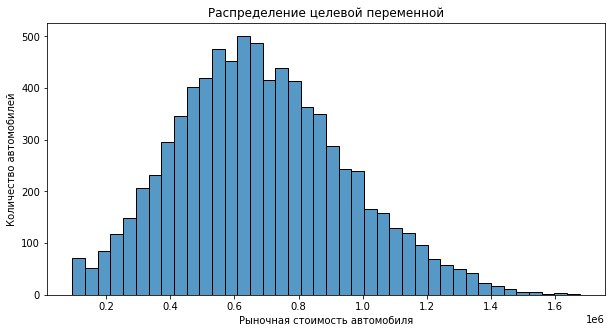

In [13]:
plt.figure(figsize=(10,5))
sns.histplot (data = df_train,
             x = 'price_rub',
             bins = 40)
plt.title('Распределение целевой переменной')
plt.xlabel('Рыночная стоимость автомобиля')
plt.ylabel ('Количество автомобилей')
plt.show()

Целевая переменная `price_rub` имеет практически нормальное распределение с небольшой правосторонней асимметрией: основная часть автомобилей имеет стоимость примерно от 400 тыс. до 1 млн руб., при этом наибольшая концентрация наблюдается в районе 600–700 тыс. руб. 
Средняя стоимость составляет около 684,6 тыс. руб., медиана — 663,9 тыс. руб. Правый хвост показывает наличие небольшого количества более дорогих автомобилей стоимостью до 1,68 млн руб.

### Анализ категориальных и числовых признаков

Построим визуализацию признаков. Столбцы, для которых подходит визуализация через столбчатую диаграмму, соберем в один список:

In [14]:
columns = [col for col in df_train.select_dtypes(include=['object', 'int64']).columns.tolist() if col!='price_rub']

In [15]:
columns

['make_year',
 'engine_cc',
 'fuel_type',
 'owner_count',
 'brand',
 'transmission',
 'color',
 'service_history',
 'accidents_reported',
 'insurance_valid',
 'region']

In [16]:
def visual_cat(df, columns):
    for column in columns:
        plt.figure(figsize = (10,6))
        df[column].value_counts().plot(kind = 'bar',
                                   rot=45,
                                   legend=False,
                                   title = f'Распределение данных по признаку {column}')
        plt.xlabel(column)
        plt.ylabel('Количество данных')
        plt.grid()
        plt.show()
    
        print('\nСтатистические показатели:\n')
        display(df[column].describe().round(3))

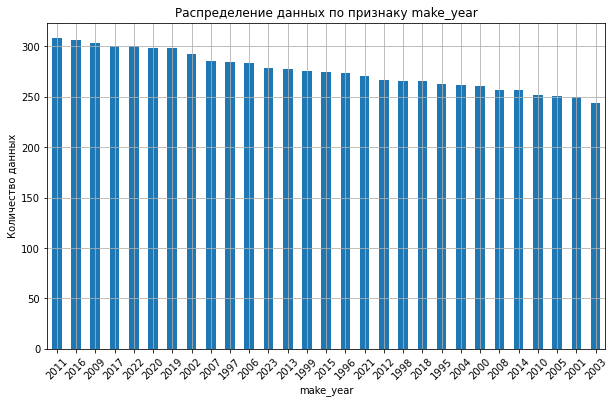


Статистические показатели:



count   8,000.000
mean    2,009.221
std         8.389
min     1,995.000
25%     2,002.000
50%     2,009.000
75%     2,017.000
max     2,023.000
Name: make_year, dtype: float64

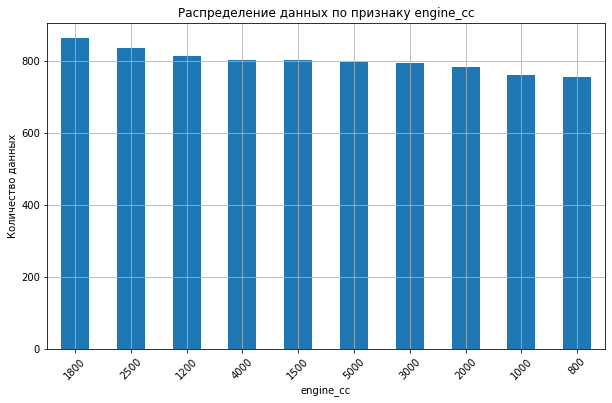


Статистические показатели:



count   8,000.000
mean    2,289.688
std     1,289.812
min       800.000
25%     1,200.000
50%     2,000.000
75%     3,000.000
max     5,000.000
Name: engine_cc, dtype: float64

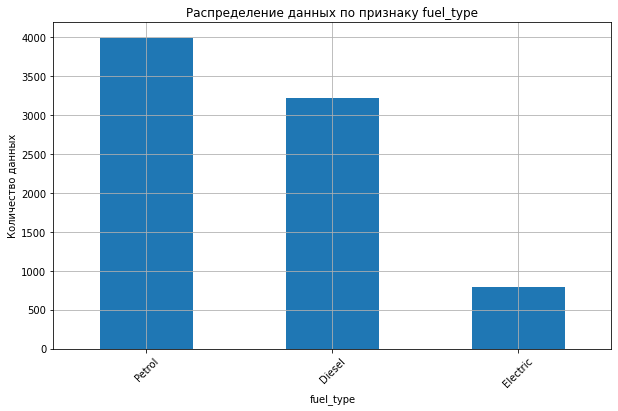


Статистические показатели:



count       8000
unique         3
top       Petrol
freq        3990
Name: fuel_type, dtype: object

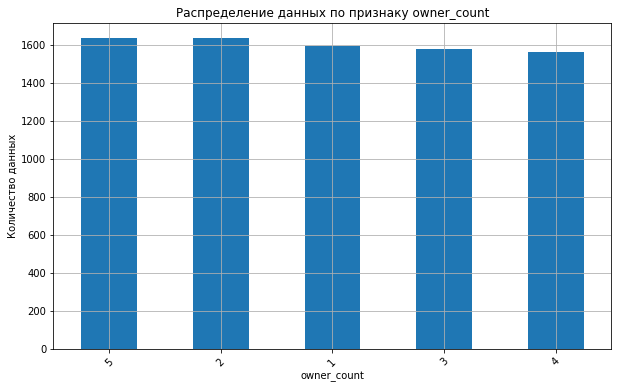


Статистические показатели:



count   8,000.000
mean        3.001
std         1.419
min         1.000
25%         2.000
50%         3.000
75%         4.000
max         5.000
Name: owner_count, dtype: float64

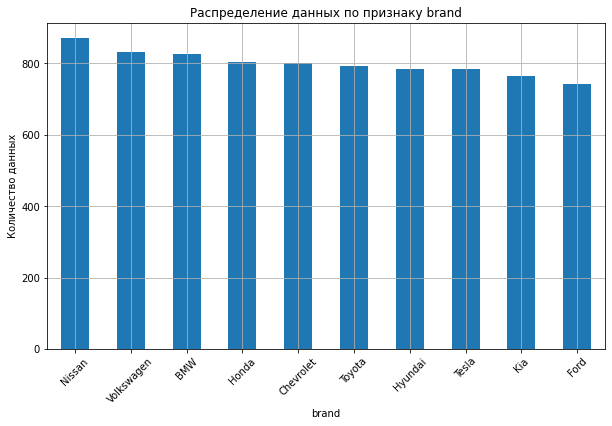


Статистические показатели:



count       8000
unique        10
top       Nissan
freq         870
Name: brand, dtype: object

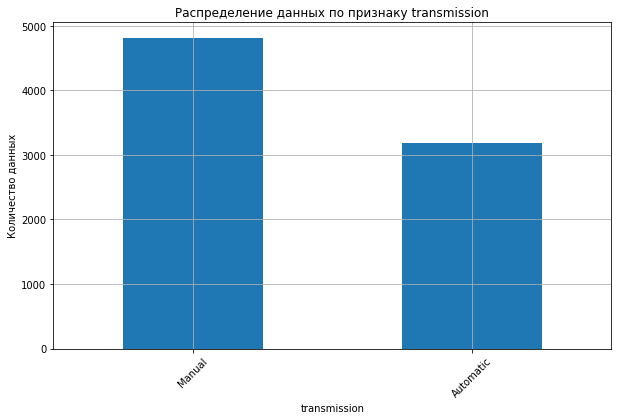


Статистические показатели:



count       8000
unique         2
top       Manual
freq        4812
Name: transmission, dtype: object

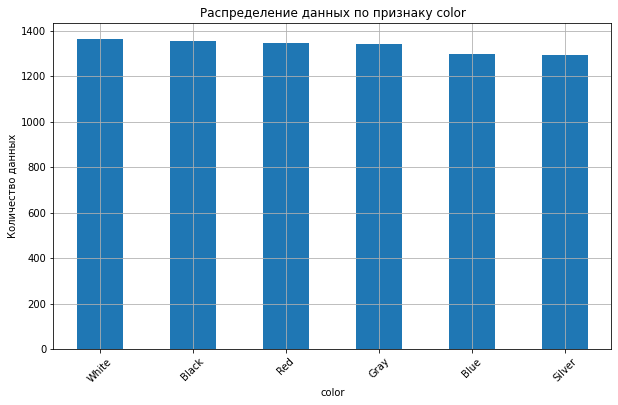


Статистические показатели:



count      8000
unique        6
top       White
freq       1366
Name: color, dtype: object

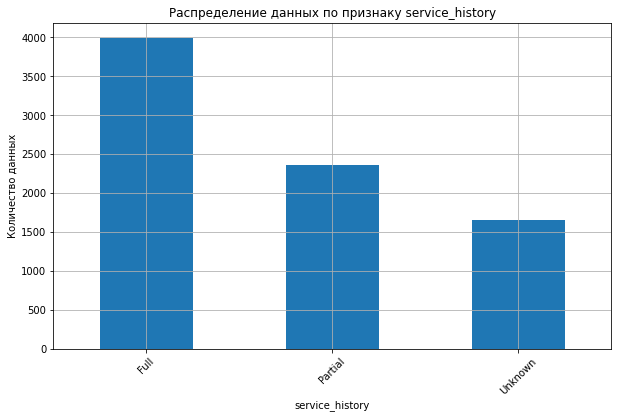


Статистические показатели:



count     8000
unique       3
top       Full
freq      3985
Name: service_history, dtype: object

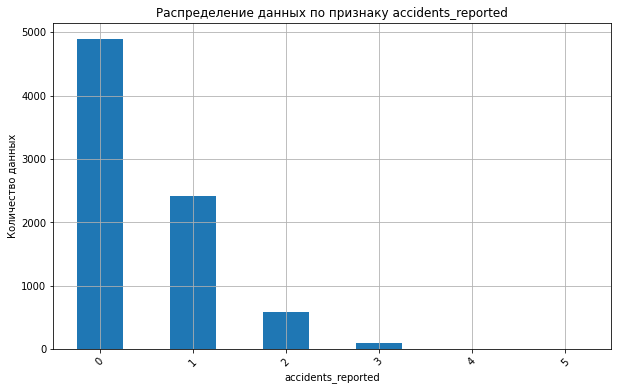


Статистические показатели:



count   8,000.000
mean        0.488
std         0.694
min         0.000
25%         0.000
50%         0.000
75%         1.000
max         5.000
Name: accidents_reported, dtype: float64

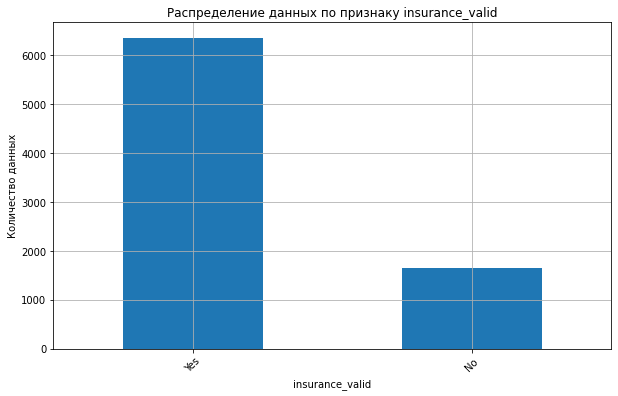


Статистические показатели:



count     8000
unique       2
top        Yes
freq      6356
Name: insurance_valid, dtype: object

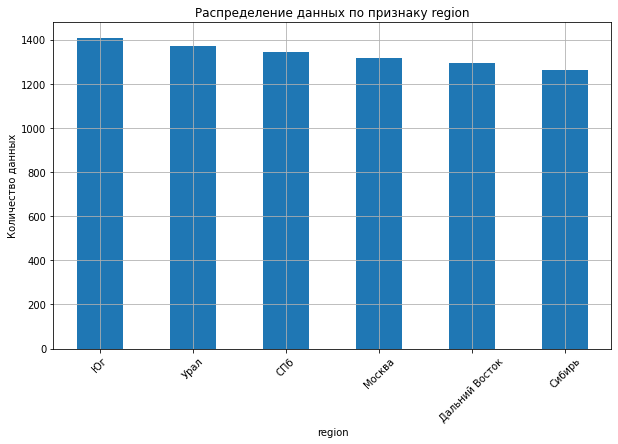


Статистические показатели:



count     8000
unique       6
top         Юг
freq      1408
Name: region, dtype: object

In [17]:
visual_cat(df_train, columns)

Построим визуализацию с помощью гистограммы и диаграммы рахмаха для признака `mileage_kmpl`:

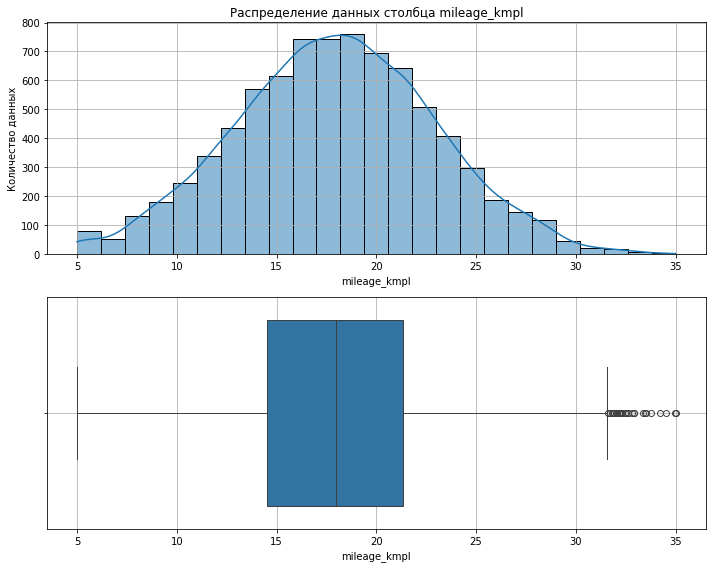

In [18]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10, 8))
    # гистограмма 
sns.histplot(data = df_train,
            x = 'mileage_kmpl',
            bins = 25,
            kde = True,
            ax= ax1)
ax1.set_title(f'Распределение данных столбца mileage_kmpl')
ax1.set_xlabel('mileage_kmpl')
ax1.set_ylabel('Количество данных')
ax1.grid()
        
    # диаграмма размаха
sns.boxplot(data = df_train,
            x='mileage_kmpl',
            ax=ax2)
ax2.grid()
        
plt.tight_layout()
plt.show()

В ходе анализа распределений признаков видно, что выборка из 8000 автомобилей в целом достаточно равномерно представлена по годам выпуска, объёму двигателя, количеству владельцев, маркам, цветам и регионам. При этом для ряда категориальных признаков наблюдается дисбаланс: бензиновые автомобили представлены чаще дизельных и электрических, механическая трансмиссия — чаще автоматической, а страховка встречается значительно чаще чем ее остутствие.

Отдельного внимания требует признак `mileage_kmpl`. Судя по диапазону значений (примерно от 5 до 35) и характеру распределения, он явно не соответствует пробегу автомобиля. Вероятнее всего, данный признак представляет собой топливную экономичность (км на литр).

### Анализ корреляции

Рассчитаем матрицу корреляций на тренировочной выборке.

In [19]:
corr_matrix = df_train.phik_matrix()
correlation_matrix = (corr_matrix[corr_matrix.index!='price_rub'][['price_rub']].sort_values(by='price_rub', 
                                                                                            ascending=False))

interval columns not set, guessing: ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported', 'price_rub']


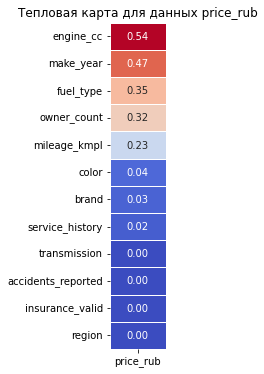

In [20]:
plt.figure(figsize=(1,6))

data_heatmap = (correlation_matrix.loc[correlation_matrix.index!='price_rub'][['price_rub']]
                .sort_values(by='price_rub', ascending=False))
sns.heatmap(data_heatmap,
           annot=True,
           fmt='.2f',
           cmap='coolwarm',
           linewidths=0.5,
           cbar=False)
plt.yticks(rotation=0)
plt.title('Тепловая карта для данных price_rub')
plt.show()

Построим полную матрицу корреляции признаков:

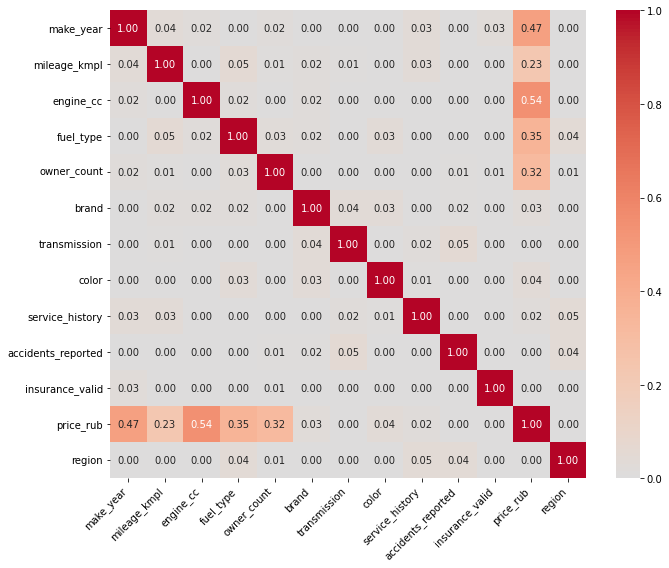

In [21]:
plt.figure(figsize=(10,8))
           
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Анализ корреляционной матрицы показал, что наиболее сильная связь с целевой переменной `price_rub` наблюдается у признаков - объём двигателя `engine_cc`(0,54), год выпуска `make_year`(0,47), тип топлива `fuel_type`(0,35) и количество владельцев `owner_count`(0,32). Связь признака расход `mileage_kmpl` с ценой слабее и составляет 0,23.

Остальные признаки имеют практически нулевую силу связи с `price_rub`: марка автомобиля `brand`(0,03), наличие сервисной книжки `service_history` (0,02), а также тип коробки передач `transmission`, количество ДТП `accidents_reported`, страховка `insurance_valid` и регион `region` (около 0,00).

Между самими признаками также практически отсутствуют выраженные корреляционные связи, что означает отсутствие мультиколлинеарности. 

### Вывод

Проведённый исследовательский анализ показал, что данные имеют однородную и согласованную структуру и подходят для построения моделей прогнозирования стоимости автомобиля. В тренировочной выборке содержится 8000 объектов, в тестовой — 2000. В обеих выборках отсутствуют пропуски и полные дубликаты, наборы категориальных значений совпадают, что позволяет использовать тестовую выборку для итоговой оценки моделей.

Целевая переменная `price_rub` имеет практически нормальное распределение с небольшой правосторонней асимметрией. Большая часть автомобилей имеет стоимость примерно от 400 до 900 тыс. руб., при этом диапазон значений достаточно широк — примерно от 95 тыс. до 1,68 млн руб. 

Анализ признаков показал, что числовые и категориальные переменные представлены достаточно разнообразно. Большинство категориальных признаков имеют небольшое количество уникальных значений. Отдельного внимания требует признак `mileage_kmpl`. По диапазону значений и форме распределения он не соответствует типичному пробегу автомобиля: значения находятся примерно в диапазоне от 5 до 35 и скорее соответствует топливной экономичности. Сам признак при этом не следует автоматически удалять, поскольку он имеет заметную связь с целевой переменной (0,23).

Корреляционный анализ показал, что наиболее выраженная сила связи с `price_rub` наблюдается у объёма двигателя `engine_cc`(0,54), года выпуска `make_year`(0,47), типа топлива `fuel_type`(0,35) и количества владельцев `owner_count`(0,32). Связь `mileage_kmpl` с ценой является более слабой (0,23). Для остальных признаков коэффициенты близки к нулю.

Между самими признаками также не обнаружено выраженных корреляционных связей, поэтому явных признаков мультиколлинеарности в данных не наблюдается.

Таким образом, EDA не выявил проблем, препятствующих дальнейшей работе. Данные не требуют очистки, однако необходимо подготовить категориальные признаки для работы с каждой библиотекой через определение категорий и приведением их к подходящему типу (для XGBoost и LightGBM).

<h3 id="section6">6. Предобработка данных</h3>

Подготовим данные для сравнения библиотек XGBoost, CatBoost и LightGBM. Создадим одинаковый набор обучающих и валидационных данных, подготовим признаки.

Сначала разделим данные `df_train` на обучение и валидацию, а также отделим целевую переменную. 

In [22]:
X = df_train.drop(columns = 'price_rub')
y = df_train['price_rub']

Выделим из тренировочных данных 20% под валидацию:

In [23]:
X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                 test_size = 0.2,
                                                 random_state = RANDOM_STATE)

Разделим целевую переменную и признаки в `df_test`.

In [24]:
X_test = df_test.drop(columns = ['price_rub'])
y_test = df_test['price_rub']

In [25]:
print ('Размер обучающей выборки:', X_train.shape)
print ('Размер валидационной выборки:', X_val.shape)
print ('Размер тестовой выборки:', X_test.shape)

Размер обучающей выборки: (6400, 12)
Размер валидационной выборки: (1600, 12)
Размер тестовой выборки: (2000, 12)


Выделим списки признаков:

In [26]:
categorical_features = X_train.select_dtypes(include =['object']).columns.tolist()
numeric_features = X_train.select_dtypes(include = ['int64','float64']).columns.tolist()

print ('Числовые признаки:', numeric_features)
print ('Категориальные признаки:', categorical_features)

Числовые признаки: ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported']
Категориальные признаки: ['fuel_type', 'brand', 'transmission', 'color', 'service_history', 'insurance_valid', 'region']


Теперь подготовим категориальные данные для работы с библиотеками.
- CatBoost принимает категориальные данные напрямую;
- LightGBM требует перевода категорий к типу `category`;
- XGBoost также работает с типом `category` через параметр `enable_categorical=True`.

Поэтому не будем отдельно разбивать данные для каждой из библиотек, а только приведем столбцы `categorical_features` в `X_train`, `X_val` и `X_test` к типу `category` сразу для всех библиотек.

In [27]:
for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')
    X_test[col] = X_test[col].astype('category')
    
print (X_train[categorical_features].info())

<class 'pandas.core.frame.DataFrame'>
Index: 6400 entries, 1467 to 7270
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   fuel_type        6400 non-null   category
 1   brand            6400 non-null   category
 2   transmission     6400 non-null   category
 3   color            6400 non-null   category
 4   service_history  6400 non-null   category
 5   insurance_valid  6400 non-null   category
 6   region           6400 non-null   category
dtypes: category(7)
memory usage: 95.1 KB
None


Изменение типа данных прошло корректно, переходим к обучению моделей.

<h3 id="section7">7. Обучение моделей в разных библиотеках</h3>

Обучим XGBoost, CatBoost и LightGBM на стандартных настройках и в качестве целевой метрики используем MAE. 

Напишем функцию для расчета метрик:

In [28]:
def calculate_metrics (y_true, y_pred):
    error_ratio = (y_pred - y_true) / y_true
    overpricing_rate = (error_ratio > 0.20).mean()  # доля переплат
    under_mask = error_ratio < -0.20
    underpricing_loss = (y_true[under_mask] - y_pred[under_mask]).sum()
    rmse = root_mean_squared_error (y_true, y_pred)
    mae = mean_absolute_error (y_true, y_pred)
    r2 = r2_score (y_true, y_pred) 
    underpricing_rate = (error_ratio < -0.20).mean()
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2' : r2,
        'Overpricing rate': overpricing_rate,
        'Underpricing loss': underpricing_loss,
        'Underpricing rate': underpricing_rate
    }

Словарь для хранения результатов:

In [29]:
results = {}

**Обучим и оценим модель `XGBRegressor`**

In [30]:
xgb_model = XGBRegressor(random_state = RANDOM_STATE,
                        enable_categorical = True,
                        objective = 'reg:absoluteerror')

In [31]:
start_time = time.time()

In [32]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, objective='reg:absoluteerror', ...)

In [33]:
train_time_xgb = time.time() - start_time

In [34]:
start_time = time.time()

In [35]:
xgb_pred = xgb_model.predict(X_val)

In [36]:
pred_time_xgb = time.time() - start_time

In [37]:
results['XGBoost'] = calculate_metrics (y_val,xgb_pred)

**Обучим и оценим модель `LGBMRegressor`**

In [38]:
lgb_model = LGBMRegressor(random_state = RANDOM_STATE,
                          objective = 'mean_absolute_error',
                          verbose = -1)
start_time = time.time()
lgb_model.fit(X_train, y_train,
             categorical_feature = categorical_features)
train_time_lgb = time.time() - start_time
start_time = time.time()
lgb_pred = lgb_model.predict(X_val)
pred_time_lgb = time.time() - start_time

In [39]:
results['LightGBM'] = calculate_metrics(y_val,lgb_pred)

**Обучим и оценим модель `CatBoostRegressor`**

In [40]:
cb_model = CatBoostRegressor(random_state = RANDOM_STATE,
                             loss_function='MAE')
start_time = time.time()
cb_model.fit(X_train,
             y_train,
             cat_features = categorical_features, 
             verbose =200)
train_time_cb = time.time() - start_time
start_time = time.time()
cb_pred = cb_model.predict(X_val)
pred_time_cb = time.time() - start_time

0:	learn: 208483.8811081	total: 76.8ms	remaining: 1m 16s
200:	learn: 73597.9750007	total: 1.06s	remaining: 4.21s
400:	learn: 70842.2333107	total: 1.93s	remaining: 2.88s
600:	learn: 69298.3274299	total: 2.74s	remaining: 1.82s
800:	learn: 68056.3250687	total: 3.66s	remaining: 909ms
999:	learn: 67118.1737524	total: 4.48s	remaining: 0us


In [41]:
results['CatBoost'] = calculate_metrics(y_val,cb_pred)

Выведем результы метрик и времени обучения:

In [42]:
metrics_base = pd.DataFrame(results).T.sort_values('MAE')

In [43]:
metrics_base

,MAE,RMSE,R2,Overpricing rate,Underpricing loss,Underpricing rate
CatBoost,"79,367.491","99,047.177",0.855,0.134,"16,699,542.262",0.064
LightGBM,"81,979.305","102,803.932",0.844,0.139,"19,556,105.100",0.073
XGBoost,"85,486.961","107,962.625",0.828,0.144,"23,654,384.219",0.081


In [44]:
times = pd.DataFrame({
    'XGBoost': (train_time_xgb, pred_time_xgb),
    'LightGBM': (train_time_lgb, pred_time_lgb),
    'CatBoost': (train_time_cb,pred_time_cb )
}, index=['Train time', 'Prediction time'])

times

,XGBoost,LightGBM,CatBoost
Train time,0.339,0.533,4.652
Prediction time,0.029,0.008,0.010


По результатам обучения моделей на стандартных настройках можно сказать, что `CatBoost` показывает лучшее качество по всем стандартным метрикам. Модель показала наименьшую среднюю абсолютную ошибку `MAE = 79 367 руб`. и наименьший RMSE = 99 047 руб. Коэффициент детерминации (0.855) также является самым высоким, что говорит о том, что модель объясняет более 85.5% дисперсии стоимости автомобилей «из коробки».

У модели `LightGBM` метрики составили -  `МАЕ = 81 979 руб.`, RMSE = 102 804 руб., R2 = 0.844. `XGBoost` показал наихудший результат среди трех алгоритмов со стандартными настройками  - `MAE = 85 487 руб.`, RMSE = 107 962 руб., R2 = 0.828.

По результам бизнес метрик, видно, что все три модели склонны завышать стоимость более чем на 20% примерно в 13-14% случаев. Однако у `CatBoost` этот показатель минимален (13.4%), в то время как `XGBoost` рискует сильнее остальных (14.4%). `CatBoost` минимизирует упущенную прибыль, показывая сумму потерь в 16.69 млн руб., тогда как у `LightGBM` потери составляют 19.55 млн руб., а у `XGBoost` —  23.65 млн руб. (на 41% больше, чем у `CatBoost`). 

`XGBoost` и `LightGBM` — лучшие по скорости обучения (0.59s и 0.15s соответственно). `CatBoost` обучается значительно медленнее (4.5s). Однако на этапе предсказания `CatBoost` отрабатывает быстрее всех (0.004s), что критически важно для работы в реальном времени.

На текущем этапе можно сформулировать гипотезу: **библиотека `CatBoost` является наиболее безопасной для бюджета компании.**

Обоснование гипотезы:
1. `CatBoost` обеспечивает самый низкий финансовый риск (Underpricing Loss), сохраняя для компании почти 7 млн рублей потенциальной выручки по сравнению с XGBoost и около 3 млн рублей по сравнению с LightGBM.
2. Минимальный показатель Overpricing Rate (13.4%) гарантирует, что компания реже будет выкупать автомобили по завышенной цене, снижая риск прямых убытков при последующей перепродаже.
3. Несмотря на более долгое обучение, скорость генерации предсказаний у `CatBoost` минимальна, что лучше подходит для быстрой оценки на сайте.

**Квантильная регрессия в CatBoost**

Дополнительно реализуем модель `CatBoost` через квартильный лосс.
Зададим несколько значений квантиля (исключаем 0.5, тк это обычная регрессия, аналог MAE).

In [45]:
alpha_values = [0.1, 0.2, 0.3, 0.4,0.6, 0.7, 0.8]

In [46]:
for alpha_value in alpha_values: 
    cbq_model = CatBoostRegressor(random_state = RANDOM_STATE,
                                 loss_function=f'Quantile:alpha={alpha_value}')
    cbq_model.fit(X_train,
                 y_train,
                 cat_features = categorical_features, 
                 verbose =200)  
    cbq_pred = cbq_model.predict(X_val)
    results[f'CatBoost Q_{alpha_value}'] = calculate_metrics(y_val,cbq_pred)

0:	learn: 41853.5441624	total: 5.44ms	remaining: 5.44s
200:	learn: 16160.8323804	total: 880ms	remaining: 3.5s
400:	learn: 15485.6145053	total: 1.67s	remaining: 2.49s
600:	learn: 15213.1293232	total: 2.4s	remaining: 1.6s
800:	learn: 15014.8137427	total: 3.15s	remaining: 782ms
999:	learn: 14860.6906718	total: 3.88s	remaining: 0us
0:	learn: 69055.9970470	total: 4.95ms	remaining: 4.95s
200:	learn: 25947.4533467	total: 881ms	remaining: 3.5s
400:	learn: 24955.6986832	total: 1.69s	remaining: 2.53s
600:	learn: 24430.4851358	total: 2.5s	remaining: 1.66s
800:	learn: 24044.7193454	total: 3.3s	remaining: 820ms
999:	learn: 23743.2672145	total: 4.08s	remaining: 0us
0:	learn: 87498.2453055	total: 5.08ms	remaining: 5.08s
200:	learn: 32170.2910451	total: 900ms	remaining: 3.58s
400:	learn: 30899.9886738	total: 1.76s	remaining: 2.63s
600:	learn: 30234.5972153	total: 2.59s	remaining: 1.72s
800:	learn: 29741.9178684	total: 3.39s	remaining: 841ms
999:	learn: 29359.7336971	total: 4.18s	remaining: 0us
0:	lear

Выведем метрики:

In [47]:
metrics_q = pd.DataFrame(results).T.sort_values('MAE')
metrics_q 

,MAE,RMSE,R2,Overpricing rate,Underpricing loss,Underpricing rate
CatBoost,"79,367.491","99,047.177",0.855,0.134,"16,699,542.262",0.064
CatBoost Q_0.6,"80,687.760","100,899.817",0.850,0.172,"10,443,248.922",0.043
LightGBM,"81,979.305","102,803.932",0.844,0.139,"19,556,105.100",0.073
CatBoost Q_0.4,"82,552.566","102,804.683",0.844,0.107,"29,786,376.969",0.109
XGBoost,"85,486.961","107,962.625",0.828,0.144,"23,654,384.219",0.081
CatBoost Q_0.7,"85,997.956","107,721.913",0.829,0.225,"4,470,314.518",0.019
CatBoost Q_0.3,"89,368.915","110,974.230",0.818,0.081,"45,497,556.997",0.160
CatBoost Q_0.8,"97,426.978","121,139.406",0.783,0.301,"1,339,442.534",0.006
CatBoost Q_0.2,"103,258.845","126,622.376",0.763,0.051,"81,099,298.794",0.279
CatBoost Q_0.1,"130,704.378","155,493.067",0.643,0.027,"139,209,617.972",0.442


По результатам полученных метрик можно сделать следующие выводы:
- **Overpricing Rate:**
 - С уменьшением параметра alpha модели начинает всё более консервативно оценивать автомобили, что ожидаемо снижает риск переплат: для модели Q_0.4 переплата падает до 10.7%, при Q_0.3 риск падает до 8.1%,при Q_0.1 риск переплаты становится минимальным — всего 2.7%.
 - С увеличением параметра alpha риск переплат растет. При Q_0.6 он равен 17.2%, а при Q_0.8 достигает 30.1% (каждая третья машина будет оценена дороже рынка).
- **Underpricing Loss:**
 - При alpha < 0.5 модели начинает недооценивать машины, что приводит к росту упущенной прибыли из-за ухода клиентов. При Q_0.4 потери возрастают до 29.79 млн руб., при Q_0.3 потери составляют 45.50 млн руб., при Q_0.1 упущенная выгода достигает 139.21 млн руб.
 - При alpha > 0.5 Underpricing Loss моделей стремится к нулю, поскольку они сильно завышают стоимость, что побуждает клиентов принимать эти предложения.
- **Применимость моделей:**
 - Модели alpha < 0.5 безопасны для бюджета выкупа, но уменьшают конверсию, так как заниженные предложения уводят клиентов к конкурентам.
 - Модели alpha > 0.5 обеспечивают максимальный поток клиентов, но несут убытки для компании из-за систематической закупки машин выше рынка.

Ни один из квантильных вариантов не превосходит базовую модель по эффективности для бизнеса. Внедрять их вместо самой точной базовой модели (MAE) не рекомендуется, так как они либо лишают компанию клиентов, либо ведут к финансовым убыткам.

In [48]:
# Удалим из словаря модели с квантилями:
keys_to_remove = [
    'CatBoost Q_0.5',
    'CatBoost Q_0.6',
    'CatBoost Q_0.4',
    'CatBoost Q_0.7',
    'CatBoost Q_0.3',
    'CatBoost Q_0.8',
    'CatBoost Q_0.2',
    'CatBoost Q_0.1'
]

for key in keys_to_remove:
    results.pop(key, None)

<h3 id="section8">8. Работа с параметрами модели (тюнинг)</h3>

Проведем подбор гиперпараметров моделей с Optuna для трех моделей.

In [49]:
# зафиксируем раннюю остановку на уровне 50-ти итераций
EARLY_STOPPING_ROUNDS = 50

**XGBoost:**

In [50]:
def objective_xgb (trial):
    
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True ),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'gamma': trial.suggest_float('gamma',1e-8,1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha',1e-8,1.0, log=True),
        'reg_lambda' : trial.suggest_float('reg_lambda',1e-8,10.0, log=True)
    }
    
    xgb_model = XGBRegressor(**params,
                             random_state = RANDOM_STATE,
                             enable_categorical = True,
                             objective = 'reg:absoluteerror',
                            early_stopping_rounds = EARLY_STOPPING_ROUNDS)
    
    xgb_model.fit(X_train,
                 y_train,
                 eval_set = [(X_val, y_val)],
                 verbose = False)
    
    xgb_pred = xgb_model.predict(X_val)
    mae = mean_absolute_error(y_val, xgb_pred)
    
    return mae
    

In [51]:
sampler = optuna.samplers.TPESampler(seed = RANDOM_STATE)
study_xgb = optuna.create_study (direction = 'minimize', sampler = sampler)
study_xgb.optimize (objective_xgb, n_trials = 50, show_progress_bar = True)

[I 2026-10-04 19:05:51,620] A new study created in memory with name: no-name-68679b7e-b558-40d0-baba-706c03b3091e


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-10-04 19:05:54,730] Trial 0 finished with value: 84522.8828125 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'gamma': 0.0006155564318973012, 'reg_alpha': 1.77071686435378e-07, 'reg_lambda': 2.5348407664333426e-07}. Best is trial 0 with value: 84522.8828125.
[I 2026-10-04 19:06:00,028] Trial 1 finished with value: 83993.75 and parameters: {'learning_rate': 0.011430983876313222, 'max_depth': 9, 'n_estimators': 1402, 'gamma': 0.004619347374377372, 'reg_alpha': 1.4610865886287176e-08, 'reg_lambda': 5.360294728728285}. Best is trial 1 with value: 83993.75.
[I 2026-10-04 19:06:00,796] Trial 2 finished with value: 81237.28125 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'gamma': 2.9324868872723725e-07, 'reg_alpha': 2.716051144654844e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 2 with value: 81237.28125.
[I 2026-10-04 19:06:01,852] Trial 3 finished with value: 81574.3984375 and par

[I 2026-10-04 19:06:46,154] Trial 27 finished with value: 81590.671875 and parameters: {'learning_rate': 0.026715622944183472, 'max_depth': 4, 'n_estimators': 964, 'gamma': 9.454721991195762e-07, 'reg_alpha': 0.00012904547517942158, 'reg_lambda': 9.13135192558734e-08}. Best is trial 21 with value: 80300.859375.
[I 2026-10-04 19:06:48,205] Trial 28 finished with value: 82905.8515625 and parameters: {'learning_rate': 0.016102868287129687, 'max_depth': 7, 'n_estimators': 1431, 'gamma': 1.5142577754887502e-06, 'reg_alpha': 0.006234029219577091, 'reg_lambda': 3.0275054970087263e-05}. Best is trial 21 with value: 80300.859375.
[I 2026-10-04 19:06:49,704] Trial 29 finished with value: 80367.3515625 and parameters: {'learning_rate': 0.02360762340163304, 'max_depth': 3, 'n_estimators': 1623, 'gamma': 0.000362446412150867, 'reg_alpha': 0.00015257583285023028, 'reg_lambda': 5.090426367560943e-07}. Best is trial 21 with value: 80300.859375.
[I 2026-10-04 19:06:51,877] Trial 30 finished with value:

**LightGBM:**

In [52]:
def objective_lbm (trial):
    
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True ),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'num_leaves': trial.suggest_int('num_leaves', 20, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 100),
        'reg_alpha': trial.suggest_float('reg_alpha',1e-8,1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8,1.0, log=True)
    }
    
    lgb_model = LGBMRegressor(**params,
                              random_state = RANDOM_STATE,
                              objective = 'mean_absolute_error',
                              verbose = -1)
    lgb_model.fit(X_train,
                  y_train,
                  eval_set=[(X_val, y_val)],
                  categorical_feature = categorical_features,
                  callbacks = [early_stopping(stopping_rounds = EARLY_STOPPING_ROUNDS, verbose=False)])
    
    lgb_pred = lgb_model.predict(X_val)
    mae = mean_absolute_error(y_val, lgb_pred)
    
    return mae

In [53]:
study_lgb = optuna.create_study (direction = 'minimize', sampler = sampler)
study_lgb.optimize (objective_lbm, n_trials = 50, show_progress_bar = True)

[I 2026-10-04 19:07:27,869] A new study created in memory with name: no-name-2dcc81f2-ba12-4754-950e-57605a5de38b


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-10-04 19:07:28,880] Trial 0 finished with value: 81357.2237712476 and parameters: {'learning_rate': 0.02447244097399012, 'max_depth': 5, 'n_estimators': 1743, 'num_leaves': 104, 'min_child_samples': 29, 'reg_alpha': 0.0002195678075127562, 'reg_lambda': 1.3408920002835378e-07}. Best is trial 0 with value: 81357.2237712476.
[I 2026-10-04 19:07:29,072] Trial 1 finished with value: 80747.6220939424 and parameters: {'learning_rate': 0.0634157277549528, 'max_depth': 3, 'n_estimators': 1981, 'num_leaves': 203, 'min_child_samples': 20, 'reg_alpha': 1.1070747281639212e-08, 'reg_lambda': 0.03339576740674938}. Best is trial 1 with value: 80747.6220939424.
[I 2026-10-04 19:07:29,508] Trial 2 finished with value: 81999.84307268338 and parameters: {'learning_rate': 0.05091635945818555, 'max_depth': 8, 'n_estimators': 1657, 'num_leaves': 37, 'min_child_samples': 36, 'reg_alpha': 8.451863533931625e-08, 'reg_lambda': 0.08032068562667222}. Best is trial 1 with value: 80747.6220939424.
[I 2026-10

[I 2026-10-04 19:07:42,385] Trial 25 finished with value: 81206.71674963595 and parameters: {'learning_rate': 0.03623524893190955, 'max_depth': 4, 'n_estimators': 637, 'num_leaves': 65, 'min_child_samples': 74, 'reg_alpha': 8.02606428721868e-08, 'reg_lambda': 8.096162567656405e-07}. Best is trial 12 with value: 80184.69473931071.
[I 2026-10-04 19:07:42,666] Trial 26 finished with value: 80043.08827066036 and parameters: {'learning_rate': 0.051523819614039276, 'max_depth': 3, 'n_estimators': 1226, 'num_leaves': 135, 'min_child_samples': 55, 'reg_alpha': 6.759068293340202e-08, 'reg_lambda': 5.479193551836013e-05}. Best is trial 26 with value: 80043.08827066036.
[I 2026-10-04 19:07:43,121] Trial 27 finished with value: 81805.23322745756 and parameters: {'learning_rate': 0.0527001024529719, 'max_depth': 6, 'n_estimators': 1543, 'num_leaves': 114, 'min_child_samples': 54, 'reg_alpha': 6.282962845833877e-07, 'reg_lambda': 0.000920533037303058}. Best is trial 26 with value: 80043.08827066036.

**CatBoost**

In [54]:
def objective_cb (trial):
    
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True ),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10)
    }          
    cb_model = CatBoostRegressor(**params,                                  
                                 random_state = RANDOM_STATE,                                  
                                 loss_function='MAE',
                                 early_stopping_rounds = EARLY_STOPPING_ROUNDS,
                                 use_best_model = True)     
    cb_model.fit(X_train,                  
                 y_train,                  
                 eval_set = [(X_val, y_val)],  
                 cat_features = categorical_features,
                 verbose = False) 
    
    cb_pred = cb_model.predict(X_val)
    mae = mean_absolute_error(y_val, cb_pred)   
    return mae

In [55]:
study_cb = optuna.create_study (direction = 'minimize', sampler = sampler)
study_cb.optimize (objective_cb, n_trials = 50, show_progress_bar = True)

[I 2026-10-04 19:07:51,680] A new study created in memory with name: no-name-e7263e25-11ba-4141-aca3-cd9d757011ce


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-10-04 19:07:54,035] Trial 0 finished with value: 79468.02098517472 and parameters: {'learning_rate': 0.02614634594933435, 'max_depth': 4, 'iterations': 679, 'l2_leaf_reg': 4}. Best is trial 0 with value: 79468.02098517472.
[I 2026-10-04 19:07:54,842] Trial 1 finished with value: 79600.37396150798 and parameters: {'learning_rate': 0.08768184989765529, 'max_depth': 5, 'iterations': 1278, 'l2_leaf_reg': 8}. Best is trial 0 with value: 79468.02098517472.
[I 2026-10-04 19:08:02,719] Trial 2 finished with value: 79994.29054022784 and parameters: {'learning_rate': 0.02310093735409802, 'max_depth': 10, 'iterations': 1944, 'l2_leaf_reg': 3}. Best is trial 0 with value: 79468.02098517472.
[I 2026-10-04 19:08:05,069] Trial 3 finished with value: 79408.50605227756 and parameters: {'learning_rate': 0.031423062259089654, 'max_depth': 5, 'iterations': 927, 'l2_leaf_reg': 1}. Best is trial 3 with value: 79408.50605227756.
[I 2026-10-04 19:08:07,817] Trial 4 finished with value: 79763.969443148

[I 2026-10-04 19:09:18,211] Trial 36 finished with value: 79578.21254286754 and parameters: {'learning_rate': 0.0303061276880434, 'max_depth': 5, 'iterations': 1121, 'l2_leaf_reg': 2}. Best is trial 17 with value: 79239.4901356899.
[I 2026-10-04 19:09:22,116] Trial 37 finished with value: 79642.54851559462 and parameters: {'learning_rate': 0.08207009946548838, 'max_depth': 9, 'iterations': 950, 'l2_leaf_reg': 4}. Best is trial 17 with value: 79239.4901356899.
[I 2026-10-04 19:09:23,166] Trial 38 finished with value: 79721.6909135587 and parameters: {'learning_rate': 0.09768789437292096, 'max_depth': 4, 'iterations': 1534, 'l2_leaf_reg': 3}. Best is trial 17 with value: 79239.4901356899.
[I 2026-10-04 19:09:27,393] Trial 39 finished with value: 79403.79975470553 and parameters: {'learning_rate': 0.034695491851521286, 'max_depth': 6, 'iterations': 1210, 'l2_leaf_reg': 1}. Best is trial 17 with value: 79239.4901356899.
[I 2026-10-04 19:09:28,835] Trial 40 finished with value: 79421.073700

Выведем лучшее значение метрик и гиперпараметры:

In [56]:
best_params_xgb = study_xgb.best_params
best_params_lgb = study_lgb.best_params
best_params_cb = study_cb.best_params

In [57]:
print('Лучшие гиперпараметры XGBoost:', best_params_xgb)
print('Лучшие гиперпараметры LightGBM:', best_params_lgb)
print('Лучшие гиперпараметры CatBoost:', best_params_cb)

Лучшие гиперпараметры XGBoost: {'learning_rate': 0.015413337979994524, 'max_depth': 3, 'n_estimators': 1357, 'gamma': 2.5378031857187254e-05, 'reg_alpha': 0.0042739691687522325, 'reg_lambda': 0.00013538073543648642}
Лучшие гиперпараметры LightGBM: {'learning_rate': 0.051523819614039276, 'max_depth': 3, 'n_estimators': 1226, 'num_leaves': 135, 'min_child_samples': 55, 'reg_alpha': 6.759068293340202e-08, 'reg_lambda': 5.479193551836013e-05}
Лучшие гиперпараметры CatBoost: {'learning_rate': 0.03236326384869857, 'max_depth': 3, 'iterations': 1116, 'l2_leaf_reg': 2}


In [58]:
print ('Лучшие значение МАЕ XGBoost:', study_xgb.best_value)
print ('Лучшие значение МАЕ LightGBM:', study_lgb.best_value)
print ('Лучшие значение МАЕ CatBoost:', study_cb.best_value)

Лучшие значение МАЕ XGBoost: 80265.40625
Лучшие значение МАЕ LightGBM: 80043.08827066036
Лучшие значение МАЕ CatBoost: 79239.4901356899


Для удобство сравнения с базовыми алгоритмами, обучим лучшие модели, подобранные через Optuna, и оценим метрики черех функцию `calculate_metrics`.

In [59]:
best_xgb = XGBRegressor(**best_params_xgb,
                        random_state = RANDOM_STATE,
                        enable_categorical = True,
                        objective = 'reg:absoluteerror',
                        early_stopping_rounds = EARLY_STOPPING_ROUNDS)

best_xgb.fit(X_train,y_train,eval_set = [(X_val, y_val)],verbose = False)
xgb_pred_tuned = best_xgb.predict(X_val)
results['XGBoost_tuned'] = calculate_metrics(y_val,xgb_pred_tuned)

In [60]:
best_lgb = LGBMRegressor(**best_params_lgb,
                        random_state = RANDOM_STATE,
                        objective = 'mean_absolute_error',
                        verbose = -1)

best_lgb.fit(X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            categorical_feature = categorical_features,
            callbacks = [early_stopping(stopping_rounds = EARLY_STOPPING_ROUNDS, verbose=False)])

lgb_pred_tuned = best_lgb.predict(X_val)
results['LightGBM_tuned'] = calculate_metrics(y_val,lgb_pred_tuned)

In [61]:
best_cb = CatBoostRegressor(**best_params_cb,                                  
                            random_state = RANDOM_STATE,                                  
                            loss_function='MAE',
                            early_stopping_rounds = EARLY_STOPPING_ROUNDS,
                            use_best_model = True)      
best_cb.fit(X_train,                  
            y_train,                  
            eval_set = [(X_val, y_val)],  
            cat_features = categorical_features,
            verbose = False) 
cb_pred_tuned = best_cb.predict(X_val)
results['CatBoost_tuned'] = calculate_metrics(y_val,cb_pred_tuned)

Выведем результаты для сравнения базовых алгоритмов с улучшенными.

In [62]:
results_optuna = pd.DataFrame(results).T.sort_values('MAE')

In [63]:
results_optuna

,MAE,RMSE,R2,Overpricing rate,Underpricing loss,Underpricing rate
CatBoost_tuned,"79,239.490","98,787.926",0.856,0.133,"16,714,637.503",0.064
CatBoost,"79,367.491","99,047.177",0.855,0.134,"16,699,542.262",0.064
LightGBM_tuned,"80,043.088","100,517.284",0.851,0.134,"18,312,896.438",0.069
XGBoost_tuned,"80,265.406","100,864.312",0.850,0.135,"19,205,071.234",0.071
LightGBM,"81,979.305","102,803.932",0.844,0.139,"19,556,105.100",0.073
XGBoost,"85,486.961","107,962.625",0.828,0.144,"23,654,384.219",0.081


По результатам оптимизации гиперпараметров с помощью Optuna все три алгоритма улучшили свои показатели.
Наилучший прирост качества продемонстрировала модель `XGBoost_tuned`. Её средняя абсолютная ошибка MAE снизилась более чем на 5 000 руб., коэффициент детерминации R² вырос до 0.850, Underpricing Loss уменьшился на 4 миллиона рублей, а риск переплаты снизился до 13.5%. 

Модель `LightGBM_tuned` после тюнинга также показала рост точности, снизив MAE почти на 2 000 рублей и уменьшив Underpricing loss на 1,2 млн руб.

Алгоритм `CatBoost` «из коробки» показал схожие результаты с оптимизированной моделью - МАЕ улучшилось на 120 руб. Несмотря на небольшое улучшение от тюнинга, `CatBoost_tuned` показывает лучшие метрики на этапе валидации с MAE на уровне 79 239 руб. С точки зрения бизнеса данная модель является наиболее безопасной, поскольку она минимизирует риски упущенной прибыли и удерживает низкую долю переплат на уровне 13.3%.

На основе полученных метрик качества и финансовых рисков модель `CatBoost_tuned` можно считать лучшей. Далее обучим данную модель на объединённом наборе данных из обучающей и валидационную выборки. Итоговая оценка обобщающей способности модели будет проведена отложенной тестовой выборке.

<h3 id="section9">9. Интерпретация и бизнес-анализ (SHAP)</h3>

Построим SHAP Summary Plot для лучших моделей после поиска Optuna, a также Dependence Plot для таких специфических признаков как `color` и `insurance_valid`.

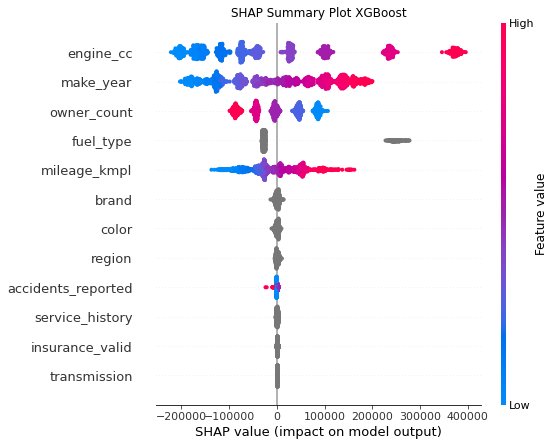

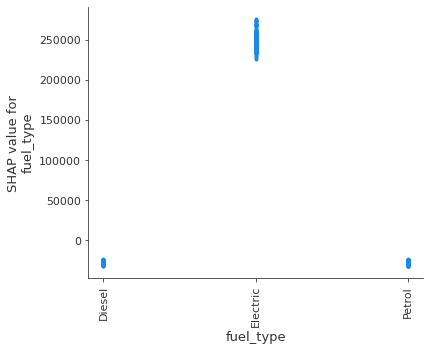

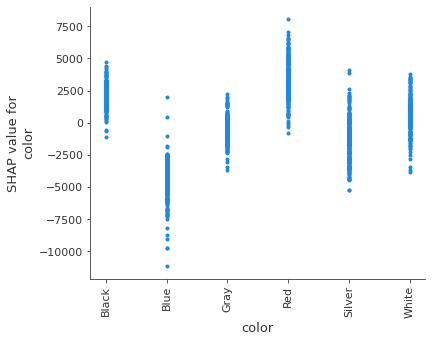

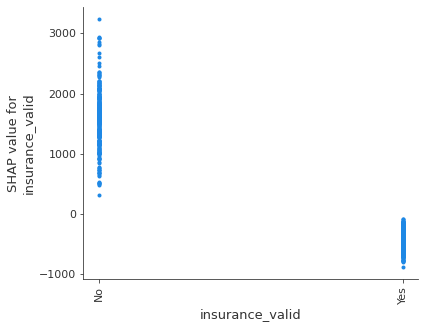

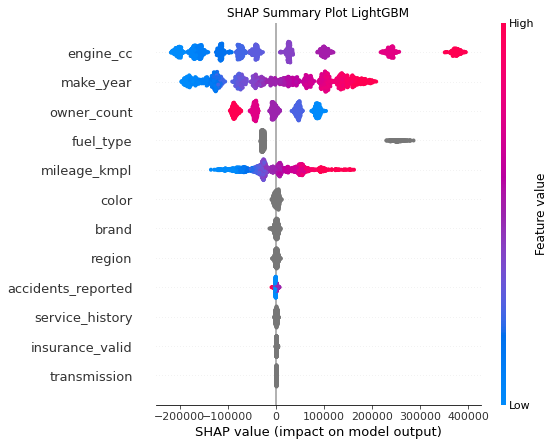

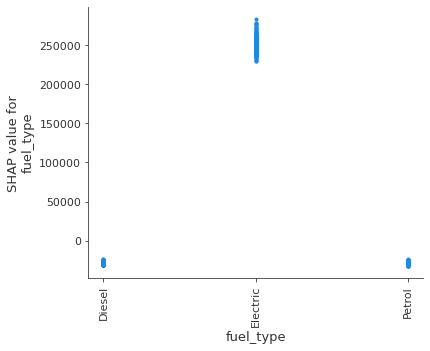

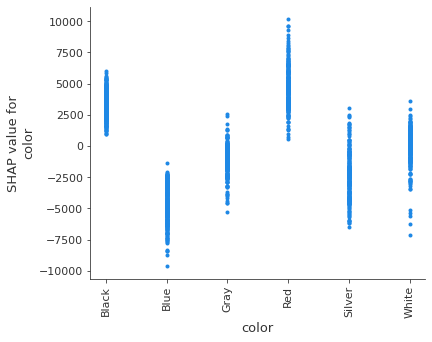

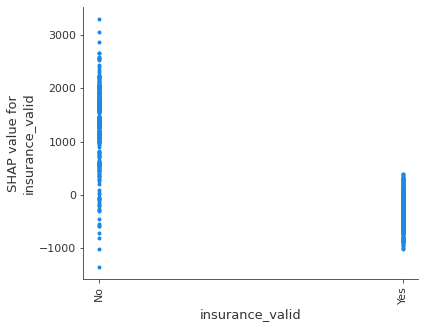

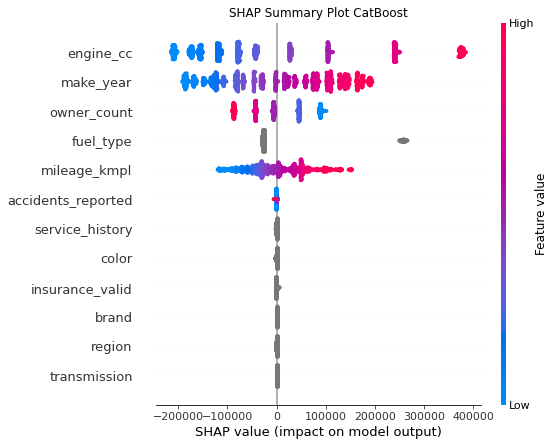

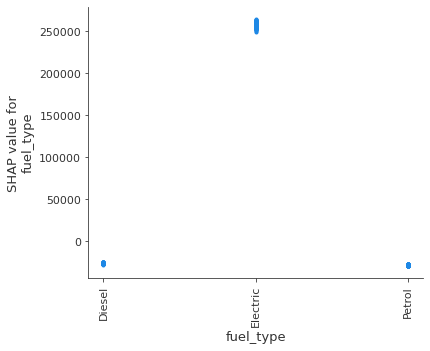

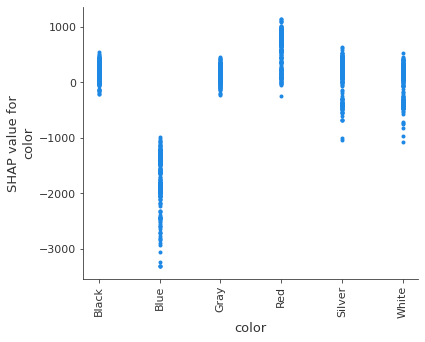

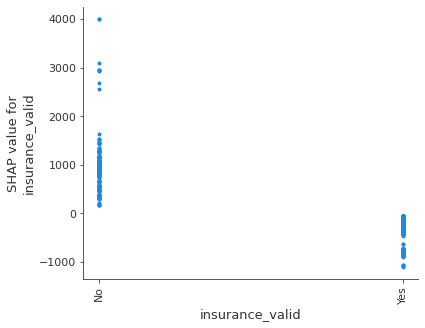

In [64]:
models = {
    'XGBoost': best_xgb,
    'LightGBM': best_lgb,
    'CatBoost': best_cb
}

for name, model in models.items():
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)
    
    plt.figure(figsize=(16,14))
    shap.summary_plot(shap_values, X_val, show = False)
    plt.title(f'SHAP Summary Plot {name}')
    plt.tight_layout()
    plt.show()
    
    shap.dependence_plot("fuel_type", shap_values, X_val, interaction_index=None)
    shap.dependence_plot("color", shap_values, X_val, interaction_index=None)
    shap.dependence_plot("insurance_valid", shap_values, X_val, interaction_index=None)

По результатам SHAP Summary Plot для XGBoost, LightGBM и CatBoost можно выделить пять наиболее значимых признаков, котороые совпадают у всех моделей:
- `engine_cc` — объём двигателя. Значения SHAP показывают, что автомобили с большим объёмом двигателя, как правило, получают более высокую предсказанную цену, а с меньшим — более низкую;
- `make_year` — год выпуска автомобиля. Более новые автомобили преимущественно увеличивают предсказанную цену, тогда как более старые снижают её;
- `owner_count` — количество владельцев. Большое количество владельцев в основном связано со снижением оценки автомобиля, а небольшое — с её повышением;
- `fuel_type` — тип топлива. Различия SHAP указывают на то, что модель учитывает тип топлива при оценке стоимости. Наиболее заметный эффект наблюдается для электромобилей, для которых вклад в прогноз существенно выше, чем для других типов топлива;
- `mileage_kmpl` — расход топлива/топливная экономичность. Чем больше км проезжает автомобиль на 1 литре бензина, тем он более привлекателен для покупателя.

Результаты моделей соответствуют ожидаемым закономерностям автомобильного рынка.

При этом влияние некоторых признаков, таких как `color` и `insurance_valid`, пренебрежимо мало по сравнению с основными факторами. Их значения SHAP находятся в пределах нескольких тысяч рублей, тогда как для наиболее значимых признаков эффект достигает сотен тысяч рублей. Кроме того, при MAE модели около 79 тыс. руб. такие небольшие различия не позволяют делать надёжные бизнес-выводы о влиянии цвета автомобиля или наличия страховки на его стоимость. Это также согласуется с низкой корреляционной связью этих признаков с ценой (Phik ≈ 0.04 для `color` и ≈ 0.00 для `insurance_valid`).

Интерпретация SHAP показала, что все три оптимизированные модели используют сходный набор основных факторов при оценке стоимости автомобиля. Наибольший вклад в предсказания вносят объём двигателя, год выпуска, количество владельцев, тип топлива и расход/топливная экономичность. Направление влияния большинства этих признаков согласуется с бизнес-логикой автомобильного рынка.

**Анализ ошибок в разрезе категорий**

Проанализируем ошибки в разрезе категорий (марки автомобилей и макро-регионов), построив матрицу ошибок по самой лучшей модели `CatBoost_tuned`. Посчитаем МАЕ, относительную ошибку, Overpricing rate и Underpricing loss через X_val и y_val.

In [65]:
errors = X_val.copy()
errors['y_val'] = y_val.values
errors['y_pred'] = cb_pred_tuned
errors['abs_error'] = abs(errors['y_pred'] - errors['y_val'])
errors['error_ratio'] = (errors['y_pred'] - errors['y_val'])/errors['y_val']
errors['overpricing'] = (errors['error_ratio'] > 0.20).astype(int)
errors['underpricing_loss'] = np.where(errors['error_ratio'] < -0.20, errors['y_val'] - errors['y_pred'],0)

Выведем ошибки по маркам автомобилей:

In [66]:
brans_errors = (errors.groupby('brand')
                .agg(N=('y_val', 'size'),
                     MAE=('abs_error', 'mean'),
                     Mean_error = ('error_ratio', 'mean'),
                     Overpricing_rate=('overpricing', 'mean'),
                     Underpricing_loss=('underpricing_loss', 'sum')
                    ).sort_values('MAE', ascending = False))
print ('Анализ ошибок по маркам автомобилей')
print ('Бренды с наибольшим МАЕ:')
display(brans_errors.head(5))

Анализ ошибок по маркам автомобилей
Бренды с наибольшим МАЕ:


/var/folders/g7/j8cypch14_d3gssy51qrcwn80000gn/T/ipykernel_12353/804909105.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brans_errors = (errors.groupby('brand')


,N,MAE,Mean_error,Overpricing_rate,Underpricing_loss
brand,,,,,
BMW,171,"86,242.467",0.025,0.111,"3,163,893.455"
Toyota,152,"85,352.279",0.044,0.184,"1,652,797.287"
Tesla,163,"85,188.000",0.065,0.147,"1,937,461.046"
Kia,167,"83,885.115",0.032,0.102,"1,897,788.579"
Hyundai,166,"77,909.887",0.041,0.120,"1,361,713.094"


In [67]:
print ('Бренды с наибольшей недооценкой :')
display(brans_errors.sort_values('Underpricing_loss', ascending = False).head(5))

Бренды с наибольшей недооценкой :


,N,MAE,Mean_error,Overpricing_rate,Underpricing_loss
brand,,,,,
BMW,171,"86,242.467",0.025,0.111,"3,163,893.455"
Volkswagen,173,"76,417.334",0.039,0.162,"2,040,288.939"
Tesla,163,"85,188.000",0.065,0.147,"1,937,461.046"
Kia,167,"83,885.115",0.032,0.102,"1,897,788.579"
Toyota,152,"85,352.279",0.044,0.184,"1,652,797.287"


Выведем ошибки по регионам:

In [68]:
region_errors = (errors.groupby('region')
                .agg(N=('y_val', 'size'),
                     MAE=('abs_error', 'mean'),
                     Mean_error = ('error_ratio', 'mean'),
                     Overpricing_rate=('overpricing', 'mean'),
                     Underpricing_loss=('underpricing_loss', 'sum')
                    ).sort_values('MAE', ascending = False))
print ('Анализ ошибок по регионам')
print ('Регионы с наибольшим МАЕ:')
display(region_errors.head(5))

Анализ ошибок по регионам
Регионы с наибольшим МАЕ:


/var/folders/g7/j8cypch14_d3gssy51qrcwn80000gn/T/ipykernel_12353/3534213972.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_errors = (errors.groupby('region')


,N,MAE,Mean_error,Overpricing_rate,Underpricing_loss
region,,,,,
Урал,276,"82,289.805",0.053,0.159,"2,072,299.066"
Сибирь,253,"80,654.203",0.051,0.154,"2,046,031.656"
Дальний Восток,262,"80,598.490",0.014,0.088,"2,944,404.752"
СПб,267,"78,087.575",0.023,0.120,"3,773,940.159"
Юг,293,"76,949.076",0.046,0.140,"3,364,725.328"


In [69]:
print ('Регоины с наибольшей недооценкой :')
display(region_errors.sort_values('Underpricing_loss', ascending = False).head(5))

Регоины с наибольшей недооценкой :


,N,MAE,Mean_error,Overpricing_rate,Underpricing_loss
region,,,,,
СПб,267,"78,087.575",0.023,0.120,"3,773,940.159"
Юг,293,"76,949.076",0.046,0.140,"3,364,725.328"
Дальний Восток,262,"80,598.490",0.014,0.088,"2,944,404.752"
Москва,249,"76,921.359",0.040,0.133,"2,513,236.542"
Урал,276,"82,289.805",0.053,0.159,"2,072,299.066"


По результатам анализа ошибок модели `CatBoost_tuned` в разрезе марок автомобилей и регионов можно выделить следующие закономерности:

 - По маркам автомобилей наибольшая средняя абсолютная ошибка наблюдается у `BMW` (86,2 тыс. руб.), `Tesla` (85,4 тыс. руб.) и `Toyota` (85,2 тыс. руб.). При этом наибольший Underpricing loss также приходится на `BMW` (3,16 млн руб.), далее следуют `Volkswagen` (2,04 млн руб.) и `Tesla` (1,94 млн руб.). Это показывает, что `BMW` и `Tesla` одновременно характеризуются высокой абсолютной ошибкой и заметной недооценкой. По Overpricing rate наиболее высокая доля существенных завышений наблюдается у `Toyota` (18,4%), `Volkswagen` (16,2%) и `Tesla` (14,7%).

 - В разрезе регионов наиболее высокий MAE наблюдается на `Урале` (82,3 тыс. руб.), `Сибири` (80,7 тыс. руб.) и `Дальнем Востоке` (80,6 тыс. руб.). Однако по недооценке результаты отличаются: максимальный Underpricing loss приходится на `СПб` (3,63 млн руб.), `Юг` (3,41 млн руб.) и `Дальний Восток` (2,94 млн руб.).

Таким образом, наиболее проблемными зонами для дополнительной экспертной проверки по маркам можно выделить `BMW`, `Tesla` и `Volkswagen`, поскольку они имеют высокие значения Underpricing loss, а `BMW` и `Tesla` также характеризуются одним из самых высоких MAE. По регионам особого внимания требуют `СПб` и `Юг`, где зафиксированы наибольшие суммарные потери от недооценки. При этом `Урал` и `Дальний Восток` характеризуются высокой средней абсолютной ошибкой, поэтому их также рекомендуется учесть для ручной проверки.

<h3 id="section10">10. Финальная проверка</h3>

Обучим лучшую модель CatBoost_tuned на объединенной тестовой и валидационной выборке, а после проверим ее на X_test.

In [70]:
X_full_train_cb = pd.concat([X_train, X_val],axis =0)
y_full_train_cb = pd.concat([y_train, y_val], axis=0)

In [71]:
best_model = CatBoostRegressor(**best_params_cb,                                  
                            random_state = RANDOM_STATE,                                  
                            loss_function='MAE')      

best_model.fit(X_full_train_cb,                  
            y_full_train_cb,
            cat_features = categorical_features,
            verbose = False) 

pred_train = best_model.predict(X_full_train_cb) #добавим для сравнения метрик
pred_test = best_model.predict(X_test)

In [72]:
results['CatBoost_test'] = calculate_metrics(y_test, pred_test)
results['CatBoost_train'] = calculate_metrics(y_full_train_cb, pred_train)

In [73]:
final_results = pd.DataFrame(results).T

In [74]:
final_results.loc[['CatBoost_test','CatBoost_tuned', 'CatBoost_train']]

,MAE,RMSE,R2,Overpricing rate,Underpricing loss,Underpricing rate
CatBoost_test,"75,530.071","94,583.433",0.875,0.129,"19,741,016.881",0.060
CatBoost_tuned,"79,239.490","98,787.926",0.856,0.133,"16,714,637.503",0.064
CatBoost_train,"74,683.321","94,352.899",0.873,0.132,"75,085,937.545",0.057


По результатам финальной проверки модель `CatBoost`, обученная на объединённой обучающей и валидационной выборках, показала на тестовой выборке следующие результаты: MAE = 75,5 тыс. руб., RMSE = 94,5 тыс. руб., R² = 0,875. То есть в среднем абсолютная ошибка прогноза составляет около 75 тыс. рублей, а модель объясняет около 87,5% вариации стоимости автомобилей.

Сравнение метрик на обучающей и тестовой выборках показывает, что выраженного переобучения не наблюдается. Значения R² практически совпадают — 0,873, а RMSE на тестовой выборке лишь немного ниже, чем на обучающей (94,5 тыс. против 94,4 тыс. руб.). MAE на тесте также составляет 74,7 тыс. руб. против 75,5 тыс. руб. на обучении. Небольшой разрыв между показателями свидетельствует о стабильной работе модели на новых данных.

С точки зрения бизнес-рисков на тестовой выборке доля завышений стоимости более чем на 20% составляет 13%, а доля недооценок более чем на 20% — 6,0%. При этом суммарный Underpricing loss составляет около 19,74 млн руб.

Таким образом, финальная модель `CatBoost` демонстрирует хорошую обобщающую способность: качество на тестовой выборке близко к качеству на обучающей, существенного падения коэффициента детерминации и роста ошибок не наблюдается. Полученная модель может быть использована для прогнозирования стоимости автомобилей, при этом прогнозы с потенциально высокой ошибкой целесообразно дополнительно направлять на экспертную проверку.

<h3 id="section11">11. Сохранение модели </h3>

In [75]:
joblib.dump(best_model, 'final_model.joblib')
print ('Файлы успешно загружены')

Файлы успешно загружены


Проверим корректность загрузки:

In [76]:
loaded_model = joblib.load('final_model.joblib')
y_loaded = loaded_model.predict(X_test)

print ('Предсказания совпадают:', np.allclose(y_loaded,pred_test))

Предсказания совпадают: True


<h3 id="section12">12. Выводы</h3>

**1. Рекомендованная модель**

По результатам сравнения библиотек XGBoost, LightGBM и CatBoost, а также поиска гиперпараметров с помощью Optuna для внедрения рекомендуется использовать CatBoost с оптимизированными гиперпараметрами (`CatBoost_tuned`).На этапе валидации данная модель показала наилучшее сочетание стандартных метрик и бизнес-показателей.После выбора модели она была переобучена на объединённой обучающей и валидационной выборках. Итоговая оценка проводилась на отложенной тестовой выборке, которая не использовалась при обучении и настройке модели.

**2. Точность оценки**

На тестовой выборке финальная модель показала:

- MAE = 75 530 руб.
- RMSE = 94 583 руб.
- R² = 0,875.

При этом качество на тестовой выборке близко к качеству на обучающей: MAE составляет 74,6 тыс. руб. против 75,53 тыс. руб., RMSE — 94,3 тыс. руб. против 94,6 тыс. руб., а R² - 0.873 против 0.875. Небольшой разрыв между метриками свидетельствует о стабильной обобщающей способности модели.

**3. Безопасность бюджета**

На тестовой выборке 12.9% прогнозов имеют завышение стоимости более чем на 20%. Доля существенных недооценок составляет 6,0%.
При выборе модели учитывались оба направления риска: завышение цены может привести к покупке автомобиля по невыгодной для компании цене, а существенное занижение — к потере клиентов и потенциальной выручки.Поэтому бизнес-метрики использовались совместно с MAE, RMSE и R², а не рассматривались изолированно.

**4. Упущенная выгода**

На тестовой выборке суммарный Underpricing Loss составляет около 19,74 млн рублей. Эта величина отражает потенциальную потерю выручки в случаях, когда модель занизила стоимость автомобиля более чем на 20%.
Полученный результат показывает, что даже при относительно высокой общей точности модели часть автомобилей требует дополнительного контроля. В первую очередь ручной пересмотр целесообразно применять к автомобилям из сегментов, где наблюдаются повышенные абсолютные ошибки или значительные потери от недооценки.

**5. Зоны риска**

Анализ ошибок модели в разрезе марок показал, что наиболее высокие значения MAE наблюдаются у:

- BMW — 86,2 тыс. руб.
- Toyota — 85,4 тыс. руб.
- Tesla — 85,2 тыс. руб.

Наибольший Underpricing Loss зафиксирован для:

- BMW — 3,16 млн руб.
- Volkswagen — 2,04 млн руб.
- Tesla — 1,94 млн руб.

В разрезе регионов наиболее высокий MAE наблюдается на:

- Урале — 82,3 тыс. руб.
- Сибири — 80,7 тыс. руб.
- Дальнем Востоке — 80,6 тыс. руб.

При этом максимальный Underpricing Loss приходится на:

- СПб — 3,63 млн руб.
- Юг — 3,41 млн руб.
- Дальний Восток — 2,94 млн руб.

Таким образом, для дополнительного контроля рекомендуется выделить BMW, Tesla и Volkswagen, а также региональные сегменты СПб, Юга, Дальнего Востока и Урала. Для таких объектов можно предусмотреть автоматическое направление прогноза на дополнительную экспертную проверку.

**6. Гиперпараметры для интеграции**

Для внедрения в мобильное приложение необходимо зафиксировать оптимальные гиперпараметры CatBoost, полученные в результате подбора Optuna, и использовать их при последующем обучении и переобучении модели.

В конфигурации модели необходимо сохранить:

* max_depth : 3 
* learning_rate : 0.03236326384869857 
* iterations : 1116 
* l2_leaf_reg : 2

**7. Вывод**

В рамках проекта AutoValue AI была разработана и исследована система автоматической оценки рыночной стоимости автомобилей. Были сравнены три алгоритма градиентного бустинга — XGBoost, LightGBM и CatBoost — и проведена оптимизация их гиперпараметров с помощью Optuna.

По совокупности стандартных метрик качества и бизнес-показателей для дальнейшего использования выбрана оптимизированная модель CatBoost. После переобучения на объединённой обучающей и валидационной выборках она показала на отложенной тестовой выборке MAE 75,5 тыс. руб., RMSE 94,6 тыс. руб. и R² 0,875.

Модель демонстрирует стабильное качество на новых данных: показатели обучения и тестирования близки, поэтому выраженных признаков переобучения не выявлено. При этом 12,9% прогнозов сопровождаются существенным завышением стоимости более чем на 20%, а 6,0% — существенным занижением. Потенциальные потери из-за недооценки автомобилей на тестовой выборке составили около 19,74 млн руб.

Дополнительный анализ показал, что точность модели неодинакова для всех сегментов рынка. Наибольшие ошибки и потенциальные потери наблюдаются для отдельных марок и регионов, поэтому для таких случаев целесообразно использовать механизм экспертной проверки.

Таким образом, разработанная модель может использоваться как инструмент автоматической предварительной оценки автомобилей в AutoValue AI. Она позволяет ускорять процесс оценки и одновременно сохранять возможность дополнительного контроля прогнозов с повышенным риском.